# 02 — Segmentation Pipeline

Convert all raw audio files from the three source databases into a unified set of 5-second mono WAV clips at 22050 Hz, organised by class and capped at 1000 clips per class.

### Output structure

```
data/segments/
    BG/
    Car/
    MC/
    Bus/
    Truck/
    Tram/
    Horn/
    Dog/
    Construction/
    Siren/
```

Each file is named `{source}_{original_stem}_{segment_idx:04d}.wav`.

### Segmentation strategy

All clips from IDMT-Traffic and Melaudis are isolated events of roughly 2 seconds. They are center-padded to 5 seconds: the event sits in the middle of the window with silence on either side, preserving natural onset and offset without truncation. UrbanSound8K clips (up to 4 seconds) are handled the same way.

| Source | Typical duration | Strategy |
|---|---|---|
| IDMT-Traffic | ~2s | center-pad to 5s |
| Melaudis BG | variable | sliding window |
| Melaudis Vehicles | ~2s | center-pad to 5s |
| US8K filtered | <=4s | center-pad to 5s |

### Cap strategy

Classes with more than 1000 candidate clips are randomly down-sampled to exactly 1000 (fixed seed). The sampling is stratified by source database so no single source is accidentally discarded. The manifest is built and inspected before any file is written.


## 0. Imports & configuration


In [2]:
import re
import shutil
import random
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import soundfile as sf
import librosa
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

In [3]:
# ── Paths ─────────────────────────────────────────────────────────────────────
ROOT        = Path("data")
IDMT_DIR    = ROOT / "IDMT_Traffic"
MEL_BG_DIR  = ROOT / "MELAUDIS_BG"
MEL_VEH_DIR = ROOT / "MELAUDIS_Vehicles"
US8K_DIR    = ROOT / "us8k_filtered"
SEG_DIR     = ROOT / "segments"        # output

# ── Audio parameters ──────────────────────────────────────────────────────────
TARGET_SR      = 22050   # Hz — standard for audio ML
TARGET_DUR     = 5.0     # seconds
TARGET_SAMPLES = int(TARGET_SR * TARGET_DUR)   # 110 250 samples

# ── Dataset parameters ────────────────────────────────────────────────────────
CAP_PER_CLASS  = 1000

CLASS2IDX = {
    'BG': 0, 'MC': 1, 'Car': 2, 'Bus': 3, 'Truck': 4,
    'Tram': 5, 'Horn': 6, 'Dog': 7, 'Construction': 8, 'Siren': 9
}
CLASSES = list(CLASS2IDX.keys())

# ── Create output folders ─────────────────────────────────────────────────────
for cls in CLASSES:
    (SEG_DIR / cls).mkdir(parents=True, exist_ok=True)

print(f"Target: {TARGET_SR} Hz | {TARGET_DUR}s | {TARGET_SAMPLES} samples")
print(f"Cap per class: {CAP_PER_CLASS}")
print(f"Output: {SEG_DIR.resolve()}")

Target: 22050 Hz | 5.0s | 110250 samples
Cap per class: 1000
Output: C:\Users\anyal\Desktop\S8\Pole_ProjetS8\data\segments


---
## 1. Core audio processing functions

`load_mono_resampled` loads any WAV file and converts it to mono at the target sample rate. `center_pad_or_trim` brings any length clip to exactly 5 seconds by padding symmetrically with zeros or trimming from both ends equally.


In [4]:
def load_mono_resampled(path: Path, sr: int = TARGET_SR) -> np.ndarray:
    """
    Load a WAV file, convert to mono (average channels), resample to `sr`.
    Returns a 1D float32 numpy array.
    """
    y, orig_sr = librosa.load(path, sr=sr, mono=True)
    return y.astype(np.float32)


def center_pad_or_trim(y: np.ndarray, n_samples: int = TARGET_SAMPLES) -> np.ndarray:
    """
    Bring a waveform to exactly `n_samples`:
    - If shorter: pad symmetrically with zeros (event stays centred).
    - If longer:  trim symmetrically (keep centre of the signal).
    """
    length = len(y)
    if length == n_samples:
        return y
    elif length < n_samples:
        pad_total = n_samples - length
        pad_left  = pad_total // 2
        pad_right = pad_total - pad_left
        return np.pad(y, (pad_left, pad_right), mode='constant')
    else:
        # Trim: keep centre
        trim_total = length - n_samples
        trim_left  = trim_total // 2
        return y[trim_left : trim_left + n_samples]


def save_segment(y: np.ndarray, path: Path, sr: int = TARGET_SR):
    """Write a float32 waveform as a 16-bit WAV."""
    sf.write(path, y, sr, subtype='PCM_16')


# ── Quick sanity check ────────────────────────────────────────────────────────
test_short = np.random.randn(int(TARGET_SR * 2)).astype(np.float32)   # 2s
test_long  = np.random.randn(int(TARGET_SR * 8)).astype(np.float32)   # 8s
assert center_pad_or_trim(test_short).shape[0] == TARGET_SAMPLES
assert center_pad_or_trim(test_long).shape[0]  == TARGET_SAMPLES
print("center_pad_or_trim: OK")

center_pad_or_trim: OK


---
## 2. Build the master manifest

Before writing a single file we build a manifest: a DataFrame listing every candidate clip with its source path, label, source database, and mic type. The cap is applied to this manifest first, then the selected clips are written to disk. This separation lets us inspect the class balance before committing to slow I/O.


### 2a. IDMT-Traffic


In [5]:
IDMT_VEHICLE_MAP = {'C': 'Car', 'M': 'MC', 'B': 'Bus', 'T': 'Truck'}
annot_path = IDMT_DIR / "annotation" / "idmt_traffic_all.txt"
audio_dir  = IDMT_DIR / "audio"

idmt_records = []
with open(annot_path) as f:
    filenames = [line.strip() for line in f if line.strip()]

for fn in filenames:
    stem  = fn.replace('.wav', '')
    parts = stem.split('_')
    fpath = audio_dir / fn
    if not fpath.exists():
        continue

    if '-BG' in fn:
        label    = 'BG'
        mic_type = parts[4] if len(parts) > 4 else 'UNK'   # ME or SE
    else:
        if len(parts) < 9:
            continue
        vehicle_code = parts[6][0]
        label = IDMT_VEHICLE_MAP.get(vehicle_code)
        if label is None:
            continue
        mic_type = parts[7]   # ME or SE

    idmt_records.append({
        'source_path': fpath,
        'label':       label,
        'source_db':   'IDMT',
        'mic_type':    mic_type,
        'file_id':     stem,   # unique ID for file-level split later
    })

idmt_manifest = pd.DataFrame(idmt_records)
print(f"IDMT manifest: {len(idmt_manifest)} entries")
print(idmt_manifest['label'].value_counts())

IDMT manifest: 17506 entries
label
BG       8144
Car      7804
Truck    1022
MC        430
Bus       106
Name: count, dtype: int64


### 2b. Melaudis BG


In [6]:
mel_bg_records = []
for wav in MEL_BG_DIR.glob("*.wav"):
    mel_bg_records.append({
        'source_path': wav,
        'label':       'BG',
        'source_db':   'MelBG',
        'mic_type':    'MelBG',
        'file_id':     wav.stem,
    })

mel_bg_manifest = pd.DataFrame(mel_bg_records)
print(f"Melaudis BG manifest: {len(mel_bg_manifest)} entries")

Melaudis BG manifest: 5792 entries


### 2c. Melaudis Vehicles


In [7]:
MEL_LABEL_RE  = re.compile(r'\d+V-([A-Za-z]+)')
KNOWN_TYPES   = ['Truck', 'Tram', 'Car', 'Bus', 'MC', 'Bic', 'NoV']
MEL_LABEL_MAP = {
    'Car': 'Car', 'Truck': 'Truck', 'Bus': 'Bus',
    'MC':  'MC',  'Tram':  'Tram',  'Bic': 'BG', 'NoV': 'BG'
}

def parse_melaudis_label(filename: str):
    m = MEL_LABEL_RE.search(filename)
    if not m:
        return None
    raw = m.group(1)
    for t in KNOWN_TYPES:
        if raw.startswith(t):
            return MEL_LABEL_MAP.get(t)
    return None

mel_veh_records = []
for wav in MEL_VEH_DIR.rglob("*.wav"):
    label    = parse_melaudis_label(wav.name)
    location = wav.parent.name   # Fitz1, SW_04, etc.
    if label is None:
        continue
    mel_veh_records.append({
        'source_path': wav,
        'label':       label,
        'source_db':   'MelVeh',
        'mic_type':    f'MelVeh_{location}',
        'file_id':     wav.stem,
    })

mel_veh_manifest = pd.DataFrame(mel_veh_records)
print(f"Melaudis Vehicles manifest: {len(mel_veh_manifest)} entries")
print(mel_veh_manifest['label'].value_counts())

Melaudis Vehicles manifest: 10527 entries
label
Car      8791
Tram      718
Truck     283
Bus       265
MC        248
BG        222
Name: count, dtype: int64


### 2d. US8K filtered


In [8]:
us8k_records = []
for split in ['train', 'val', 'test']:
    split_dir = US8K_DIR / split
    if not split_dir.exists():
        continue
    for class_dir in split_dir.iterdir():
        if not class_dir.is_dir():
            continue
        for wav in class_dir.glob("*.wav"):
            us8k_records.append({
                'source_path': wav,
                'label':       class_dir.name,
                'source_db':   'US8K',
                'mic_type':    'US8K',
                'file_id':     wav.stem,
            })

us8k_manifest = pd.DataFrame(us8k_records)
print(f"US8K manifest: {len(us8k_manifest)} entries")
print(us8k_manifest['label'].value_counts())

US8K manifest: 4358 entries
label
Construction    2000
Dog             1000
Siren            929
Horn             429
Name: count, dtype: int64


### 2e. Merge & apply cap

All sources are merged into one manifest. For each class with more than 1000 clips, a random sample of exactly 1000 is drawn, stratified by source database.


In [9]:
full_manifest = pd.concat(
    [idmt_manifest, mel_bg_manifest, mel_veh_manifest, us8k_manifest],
    ignore_index=True
)

print(f"Full manifest before cap: {len(full_manifest)} clips")
print("\nPer class:")
print(full_manifest['label'].value_counts())

Full manifest before cap: 38183 clips

Per class:
label
Car             16595
BG              14158
Construction     2000
Truck            1305
Dog              1000
Siren             929
Tram              718
MC                678
Horn              429
Bus               371
Name: count, dtype: int64


In [10]:
def stratified_cap(df: pd.DataFrame, label_col: str, source_col: str,
                   cap: int, seed: int = SEED) -> pd.DataFrame:
    """
    For each class exceeding `cap`, sample proportionally from each source database
    so no single source is wiped out.
    Classes below the cap are kept in full.
    """
    rng    = np.random.default_rng(seed)
    result = []

    for label, group in df.groupby(label_col):
        if len(group) <= cap:
            result.append(group)
            continue

        # Compute per-source proportional quota
        source_counts = group[source_col].value_counts()
        total         = len(group)
        quota         = (source_counts / total * cap).round().astype(int)

        # Adjust rounding errors so quota sums exactly to cap
        diff = cap - quota.sum()
        if diff != 0:
            quota.iloc[0] += diff

        sampled_parts = []
        for src, n in quota.items():
            src_group = group[group[source_col] == src]
            n_take    = min(n, len(src_group))
            idx       = rng.choice(len(src_group), size=n_take, replace=False)
            sampled_parts.append(src_group.iloc[idx])

        result.append(pd.concat(sampled_parts))

    return pd.concat(result, ignore_index=True)


capped_manifest = stratified_cap(full_manifest, 'label', 'source_db', CAP_PER_CLASS)
capped_manifest = capped_manifest.sample(frac=1, random_state=SEED).reset_index(drop=True)

print(f"Manifest after cap: {len(capped_manifest)} clips")
print("\nPer class:")
print(capped_manifest['label'].value_counts())
print("\nSource distribution within capped manifest:")
print(capped_manifest.groupby(['label', 'source_db']).size().unstack(fill_value=0))

Manifest after cap: 8125 clips

Per class:
label
Car             1000
Construction    1000
Truck           1000
Dog             1000
BG              1000
Siren            929
Tram             718
MC               678
Horn             429
Bus              371
Name: count, dtype: int64

Source distribution within capped manifest:
source_db     IDMT  MelBG  MelVeh  US8K
label                                  
BG             575    409      16     0
Bus            106      0     265     0
Car            470      0     530     0
Construction     0      0       0  1000
Dog              0      0       0  1000
Horn             0      0       0   429
MC             430      0     248     0
Siren            0      0       0   929
Tram             0      0     718     0
Truck          783      0     217     0


### 2f. Class balance and source mix

Inspect the final manifest before writing anything to disk.


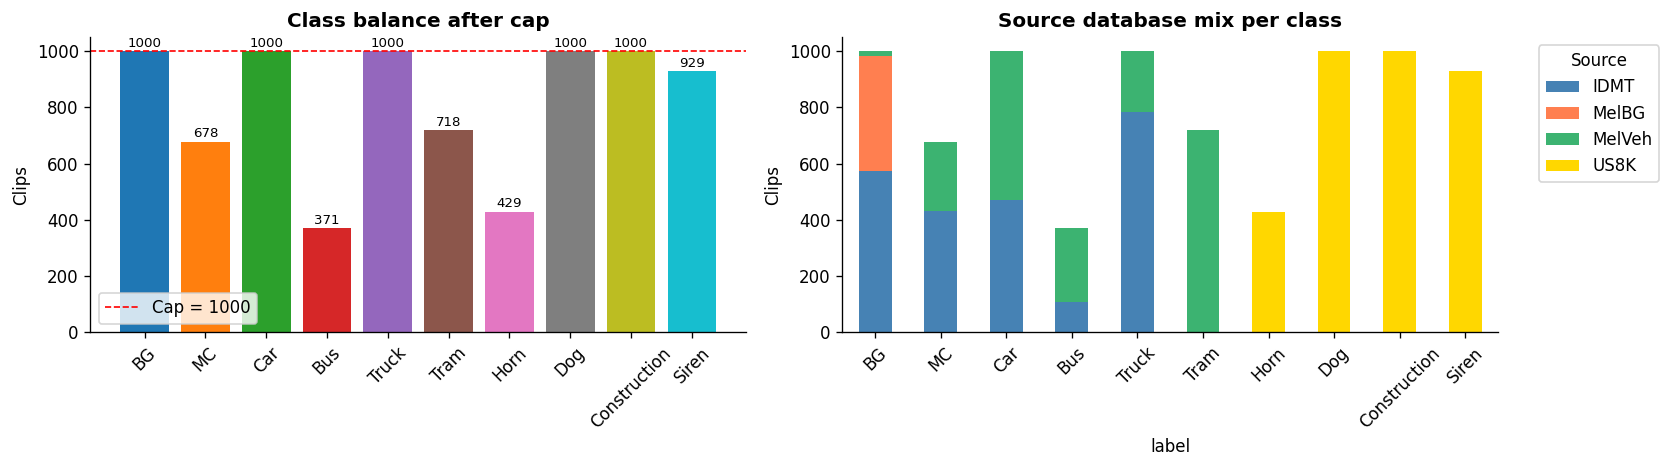

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# ── Left: class balance ───────────────────────────────────────────────────────
counts = capped_manifest['label'].value_counts().reindex(CLASSES)
colors = plt.cm.tab10.colors
bars   = axes[0].bar(counts.index, counts.values,
                     color=[colors[CLASS2IDX[c]] for c in counts.index])
axes[0].axhline(CAP_PER_CLASS, color='red', linestyle='--', linewidth=1,
                label=f'Cap = {CAP_PER_CLASS}')
axes[0].set_title('Class balance after cap', fontweight='bold')
axes[0].set_ylabel('Clips')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend()
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 str(val), ha='center', va='bottom', fontsize=8)

# ── Right: stacked source mix per class ──────────────────────────────────────
mix = capped_manifest.groupby(['label', 'source_db']).size().unstack(fill_value=0)
mix = mix.reindex(CLASSES)
mix.plot(kind='bar', stacked=True, ax=axes[1],
         color=['steelblue', 'coral', 'mediumseagreen', 'gold'])
axes[1].set_title('Source database mix per class', fontweight='bold')
axes[1].set_ylabel('Clips')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(title='Source', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.savefig('02_manifest_balance.png', bbox_inches='tight')
plt.show()

---
## 3. Write segments to disk

For each clip in the manifest: load, convert to mono, resample to 22050 Hz, center-pad or trim to 5 seconds, write as 16-bit WAV.

Expected runtime on CPU: 5 to 15 minutes depending on disk speed (mostly I/O bound).


In [12]:
errors   = []
written  = defaultdict(int)
out_records = []   # will become our final manifest with output paths

for idx, row in tqdm(capped_manifest.iterrows(), total=len(capped_manifest),
                     desc='Writing segments'):
    src_path = Path(row['source_path'])
    label    = row['label']
    source   = row['source_db']

    # Output filename: source_fileid_NNNN.wav
    out_name = f"{source}_{src_path.stem}_{written[label]:04d}.wav"
    out_path = SEG_DIR / label / out_name

    try:
        y = load_mono_resampled(src_path)
        y = center_pad_or_trim(y)
        save_segment(y, out_path)
        written[label] += 1
        out_records.append({
            **row.to_dict(),
            'out_path': out_path,
        })
    except Exception as e:
        errors.append({'file': str(src_path), 'error': str(e)})

print(f"\nOK: Done. Segments written per class:")
for cls in CLASSES:
    print(f"  {cls:<15} {written[cls]:>5}")

if errors:
    print(f"\nWARNING:  {len(errors)} errors:")
    for e in errors[:10]:
        print(f"  {e['file']}: {e['error']}")

Writing segments:   0%|          | 0/8125 [00:00<?, ?it/s]


OK: Done. Segments written per class:
  BG               1000
  MC                678
  Car              1000
  Bus               371
  Truck            1000
  Tram              718
  Horn              429
  Dog              1000
  Construction     1000
  Siren             929


---
## 4. Save the manifest

The manifest CSV maps every output segment back to its source file, label, and database. This file is the input to all subsequent notebooks.


In [13]:
final_manifest = pd.DataFrame(out_records)
final_manifest['out_path'] = final_manifest['out_path'].astype(str)
final_manifest['label_idx'] = final_manifest['label'].map(CLASS2IDX)

manifest_path = ROOT / "segments_manifest.csv"
final_manifest.to_csv(manifest_path, index=False)

print(f"Manifest saved -> {manifest_path}")
print(f"Total segments: {len(final_manifest)}")
print("\nColumns:", list(final_manifest.columns))
final_manifest.head()

Manifest saved -> data\segments_manifest.csv
Total segments: 8125

Columns: ['source_path', 'label', 'source_db', 'mic_type', 'file_id', 'out_path', 'label_idx']


,source_path,label,source_db,mic_type,file_id,out_path,label_idx
0,data\IDMT_Traffic\audio\2019-11-19-15-25_Lange...,Car,IDMT,ME,2019-11-19-15-25_Langewiesener-Strasse_50Kmh_3...,data\segments\Car\IDMT_2019-11-19-15-25_Langew...,2
1,data\us8k_filtered\train\Horn\72567-1-4-1.wav,Horn,US8K,US8K,72567-1-4-1,data\segments\Horn\US8K_72567-1-4-1_0000.wav,6
2,data\MELAUDIS_Vehicles\SW_07\2023-08-04_12-6-3...,MC,MelVeh,MelVeh_SW_07,2023-08-04_12-6-33.0-Swanston7_FF_1V-MC_L1_1La...,data\segments\MC\MelVeh_2023-08-04_12-6-33.0-S...,1
3,data\us8k_filtered\train\Construction\31884-7-...,Construction,US8K,US8K,31884-7-0-3,data\segments\Construction\US8K_31884-7-0-3_00...,8
4,data\MELAUDIS_Vehicles\SW_08\2023-08-04_14-11-...,Truck,MelVeh,MelVeh_SW_08,2023-08-04_14-11-52.0-Swanston8_FF_1V-Truck_L1...,data\segments\Truck\MelVeh_2023-08-04_14-11-52...,4


---
## 5. Verification

Load 20 randomly sampled written files and confirm they are exactly 5 seconds at 22050 Hz, mono.


In [14]:
import soundfile as sf

print("Spot-checking written segments...\n")
rng = np.random.default_rng(SEED)
sample_rows = final_manifest.sample(20, random_state=SEED)

all_ok = True
for _, row in sample_rows.iterrows():
    info = sf.info(row['out_path'])
    ok   = (info.samplerate == TARGET_SR and
            info.channels   == 1 and
            abs(info.duration - TARGET_DUR) < 0.01)
    if not ok:
        print(f"  FAIL: {row['out_path']}  sr={info.samplerate} ch={info.channels} dur={info.duration:.3f}s")
        all_ok = False

if all_ok:
    print(f"OK: All 20 sampled files: {TARGET_SR} Hz | mono | {TARGET_DUR}s")

Spot-checking written segments...

OK: All 20 sampled files: 22050 Hz | mono | 5.0s


---
## 6. Waveform check

For each class, plot the waveform of one written segment to visually confirm that center-padding looks correct.


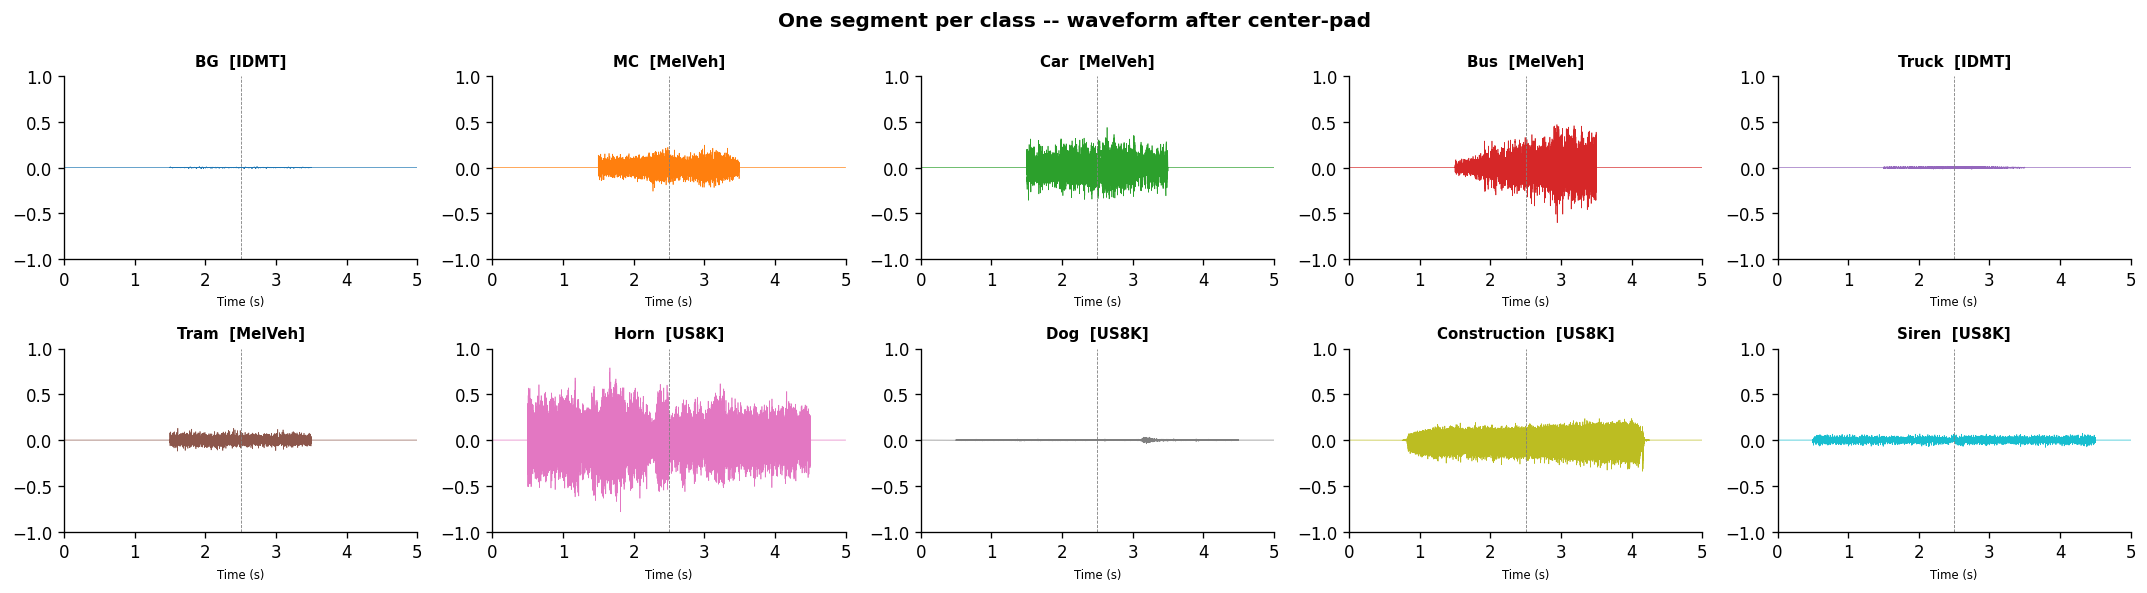

In [15]:
import librosa.display
from IPython.display import Audio, display

fig, axes = plt.subplots(2, 5, figsize=(18, 5))
fig.suptitle('One segment per class -- waveform after center-pad', fontweight='bold')
axes = axes.flatten()

for i, cls in enumerate(CLASSES):
    subset = final_manifest[final_manifest['label'] == cls]
    if len(subset) == 0:
        axes[i].set_title(f"{cls} -- no data")
        continue
    row    = subset.sample(1, random_state=SEED).iloc[0]
    y, sr  = librosa.load(row['out_path'], sr=None, mono=True)
    times  = np.linspace(0, len(y)/sr, len(y))

    axes[i].plot(times, y, linewidth=0.4, color=plt.cm.tab10.colors[CLASS2IDX[cls]])
    axes[i].set_title(f"{cls}  [{row['source_db']}]", fontsize=9, fontweight='bold')
    axes[i].set_xlim(0, TARGET_DUR)
    axes[i].set_ylim(-1, 1)
    axes[i].axvline(TARGET_DUR/2, color='gray', linewidth=0.5, linestyle='--')  # centre marker
    axes[i].set_xlabel('Time (s)', fontsize=7)

plt.tight_layout()
plt.savefig('02_segment_waveforms.png', bbox_inches='tight')
plt.show()

---
## 7. Summary


In [16]:
total = len(final_manifest)
print("=" * 60)
print("SEGMENTATION SUMMARY")
print("=" * 60)
print(f"  Sample rate   : {TARGET_SR} Hz")
print(f"  Duration      : {TARGET_DUR}s ({TARGET_SAMPLES} samples)")
print(f"  Channels      : mono")
print(f"  Cap per class : {CAP_PER_CLASS}")
print(f"  Total segments: {total}")
print(f"  Manifest      : {manifest_path}")
print()
print(f"  {'Class':<15} {'Segments':>9} {'Sources'}")
print("  " + "-" * 50)
for cls in CLASSES:
    sub     = final_manifest[final_manifest['label'] == cls]
    srcs    = ', '.join(sorted(sub['source_db'].unique()))
    print(f"  {cls:<15} {len(sub):>9}   {srcs}")
print()


SEGMENTATION SUMMARY
  Sample rate   : 22050 Hz
  Duration      : 5.0s (110250 samples)
  Channels      : mono
  Cap per class : 1000
  Total segments: 8125
  Manifest      : data\segments_manifest.csv

  Class            Segments Sources
  --------------------------------------------------
  BG                   1000   IDMT, MelBG, MelVeh
  MC                    678   IDMT, MelVeh
  Car                  1000   IDMT, MelVeh
  Bus                   371   IDMT, MelVeh
  Truck                1000   IDMT, MelVeh
  Tram                  718   MelVeh
  Horn                  429   US8K
  Dog                  1000   US8K
  Construction         1000   US8K
  Siren                 929   US8K

